In [1]:
import os
import pandas as pd
import shutil

# Paths
csv_path = r"D:\PD_1YEAR_7_08_2025.csv"
base_source_dir = r"D:\PD_1YEAR"
output_dir = r"D:\PD_dataset"

# Create output directories for each group
groups = ["PD", "Control", "Prodromal"]
for group in groups:
    os.makedirs(os.path.join(output_dir, group), exist_ok=True)

# Load the CSV
df = pd.read_csv(csv_path)

# Store the exact filenames that should be copied
expected_files = set()

# Loop through CSV and track expected file names
for index, row in df.iterrows():
    subject_id = str(row["Subject"])
    group = row["Group"]

    for root, dirs, files in os.walk(base_source_dir):
        for file in files:
            if file.endswith('.nii') or file.endswith('.nii.gz'):
                if subject_id in file:
                    expected_files.add(file)  # Store exact filename

# Track copied files
copied_files = set()

# Loop through source directory again and copy only expected files
for root, dirs, files in os.walk(base_source_dir):
    for file in files:
        if file in expected_files:  # Copy only exact matches
            for index, row in df.iterrows():
                subject_id = str(row["Subject"])
                group = row["Group"]
                
                if subject_id in file:
                    dest_folder = os.path.join(output_dir, group)
                    os.makedirs(dest_folder, exist_ok=True)
                    
                    source_file = os.path.join(root, file)
                    dest_file = os.path.join(dest_folder, file)
                    
                    shutil.copy(source_file, dest_file)
                    copied_files.add(file)
                    print(f"✅ Copied {source_file} to {dest_file}")
                    break  # Stop checking once copied

# Final verification
extra_files = copied_files - expected_files

print(f"\n✅ Successfully copied images for {len(copied_files)} subjects.")
print(f"⚠️ {len(extra_files)} extra images were copied.")

# Save extra images for review
if extra_files:
    with open(r"D:\PD_dataset1\extra_copied_files.txt", "w") as f:
        for file in extra_files:
            f.write(f"{file}\n")
    print("⚠️ Extra copied files list saved for review.")


✅ Copied D:\PD_1YEAR\PPMI\14426\T2_in_T1-anatomical_space\2014-02-26_10_55_06.0\I848771\PPMI_14426_MR_T2_in_T1-anatomical_space_Br_20170508190427151_S214219_I848771.nii to D:\PD_dataset\Prodromal\PPMI_14426_MR_T2_in_T1-anatomical_space_Br_20170508190427151_S214219_I848771.nii
✅ Copied D:\PD_1YEAR\PPMI\15761\T2_in_T1-anatomical_space\2014-09-30_10_41_01.0\I476237\PPMI_15761_MR_T2_in_T1-anatomical_space_Br_20150304180200960_S234683_I476237.nii to D:\PD_dataset\Prodromal\PPMI_15761_MR_T2_in_T1-anatomical_space_Br_20150304180200960_S234683_I476237.nii
✅ Copied D:\PD_1YEAR\PPMI\16644\T2_in_T1-anatomical_space\2015-10-29_12_44_34.0\I696553\PPMI_16644_MR_T2_in_T1-anatomical_space_Br_20160429155748506_S331751_I696553.nii to D:\PD_dataset\Prodromal\PPMI_16644_MR_T2_in_T1-anatomical_space_Br_20160429155748506_S331751_I696553.nii
✅ Copied D:\PD_1YEAR\PPMI\17608\T2_in_T1-anatomical_space\2015-01-15_11_35_44.0\I526343\PPMI_17608_MR_T2_in_T1-anatomical_space_Br_20151014165432583_S248491_I526343.nii 

In [2]:
import os

# Path to copied dataset
output_dir = r"D:\PD_dataset"

# Count files in each group
total_copied = 0
group_counts = {}

for group in ["PD", "Control", "Prodromal"]:
    group_path = os.path.join(output_dir, group)
    if os.path.exists(group_path):
        count = len([f for f in os.listdir(group_path) if f.endswith('.nii') or f.endswith('.nii.gz')])
        group_counts[group] = count
        total_copied += count

# Print results
print("📊 File count per group:")
for group, count in group_counts.items():
    print(f"  {group}: {count}")

print(f"\n✅ Total copied files: {total_copied}")
print(f"📌 Expected: 498, Copied: {total_copied}")

# Check for mismatches
if total_copied == 498:
    print("🎉 All files copied correctly!")
elif total_copied < 498:
    print(f"❌ {498 - total_copied} images are missing!")
elif total_copied > 498:
    print(f"⚠️ {total_copied - 498} extra images found!")


📊 File count per group:
  PD: 333
  Control: 115
  Prodromal: 50

✅ Total copied files: 498
📌 Expected: 498, Copied: 498
🎉 All files copied correctly!


In [3]:
import os
import pandas as pd

# Paths
csv_path = r"D:\PD_1YEAR_7_08_2025.csv"
output_dir = r"D:\PD_dataset"

# Load CSV
df = pd.read_csv(csv_path)
expected_subjects = set(df["Subject"].astype(str))

# Track extra files
extra_files = []

# Check copied files
for group in ["PD", "Control", "Prodromal"]:
    group_path = os.path.join(output_dir, group)
    if os.path.exists(group_path):
        for file in os.listdir(group_path):
            found = False
            for subject_id in expected_subjects:
                if subject_id in file:
                    found = True
                    break  
            if not found:
                extra_files.append(file)

# Print and save extra files
print(f"\n⚠️ {len(extra_files)} extra files found.")

if extra_files:
    with open(r"D:\PD_dataset1\extra_files.txt", "w") as f:
        for file in extra_files:
            f.write(f"{file}\n")
    print("⚠️ Extra file list saved as extra_files.txt")



⚠️ 0 extra files found.


In [27]:
# Split dataset into train, test, and validation sets
import os 
import shutil
import random
from sklearn.model_selection import train_test_split

# Paths
dataset_dir = r"D:\PD_dataset"  # The folder where your images are stored
output_dir = r"D:\PD_dataset_split"  # Where the split dataset will be saved

# Define categories (should match your dataset2 subfolder names)
categories = ["PD", "Control", "Prodromal"]

# Split ratios
train_ratio = 0.8
test_ratio = 0.1
val_ratio = 0.1

# Ensure output directories exist
for split in ["train", "test", "val"]:
    for category in categories:
        os.makedirs(os.path.join(output_dir, split, category), exist_ok=True)

# Process each category
for category in categories:
    category_path = os.path.join(dataset_dir, category)
    images = [f for f in os.listdir(category_path) if f.endswith(".nii") or f.endswith(".nii.gz")]

    # Shuffle images to ensure random distribution
    random.shuffle(images)

    # Split dataset
    train_files, test_val_files = train_test_split(images, test_size=(test_ratio + val_ratio), random_state=42)
    test_files, val_files = train_test_split(test_val_files, test_size=val_ratio / (test_ratio + val_ratio), random_state=42)

    # Move files to corresponding folders
    for file, split in zip([train_files, test_files, val_files], ["train", "test", "val"]):
        for img in file:
            src = os.path.join(category_path, img)
            dst = os.path.join(output_dir, split, category, img)
            shutil.copy(src, dst)

    # Print summary for this category
    print(f"📂 {category}: {len(train_files)} train, {len(test_files)} test, {len(val_files)} val")

print("✅ Dataset split complete! Check the 'PD_dataset_split' folder.")


📂 PD: 266 train, 33 test, 34 val
📂 Control: 92 train, 11 test, 12 val
📂 Prodromal: 40 train, 5 test, 5 val
✅ Dataset split complete! Check the 'PD_dataset_split' folder.


In [28]:
import os
import re
import shutil
import pandas as pd

# Paths
csv_file = r"D:\PD_1YEAR_7_08_2025.csv"        # CSV file path
dataset_dir = r"D:\PD_dataset_split"           # Folder containing train/test/val

# Load CSV
df = pd.read_csv(csv_file)

# Ensure required columns are present
if "Image Data ID" not in df.columns or "Group" not in df.columns:
    raise ValueError("CSV must contain 'Image Data ID' and 'Group' columns.")

# Create a mapping from Image Data ID to Group label
image_label_mapping = {str(row["Image Data ID"]): row["Group"] for _, row in df.iterrows()}

# Regex to extract Ixxxxxx from filename
pattern = re.compile(r"(?:.*_)?I(\d+)\.nii(?:\.gz)?$")

# Process splits
for split in ["train", "test", "val"]:
    split_path = os.path.join(dataset_dir, split)

    for category in os.listdir(split_path):  # Initially: PD, Control, Prodromal
        category_path = os.path.join(split_path, category)

        for filename in os.listdir(category_path):
            file_path = os.path.join(category_path, filename)

            # Skip already renamed files
            if re.match(r"I\d+_(PD|Control|Prodromal)\.nii(\.gz)?$", filename):
                continue

            match = pattern.match(filename)
            if match:
                image_id = f"I{match.group(1)}"
                ext = ".nii.gz" if filename.endswith(".nii.gz") else ".nii"

                if image_id in image_label_mapping:
                    label = image_label_mapping[image_id]
                    new_filename = f"{image_id}_{label}{ext}"
                    new_folder = os.path.join(split_path, label)
                    new_path = os.path.join(new_folder, new_filename)

                    # Make sure the target folder exists
                    os.makedirs(new_folder, exist_ok=True)

                    # Rename and move the file
                    shutil.move(file_path, new_path)

                    print(f"✅ Moved & Renamed: {filename} ➝ {new_filename} in {split}/{label}")
                else:
                    print(f"⚠️ Warning: Image ID {image_id} not found in CSV, skipping.")
            else:
                print(f"❌ No match for filename: {filename}")

print("✅ Renaming and relocation complete!")


✅ Moved & Renamed: PPMI_3104_MR_T2_in_T1-anatomical_space_Br_20120904142035472_S148994_I330131.nii ➝ I330131_Control.nii in train/Control
✅ Moved & Renamed: PPMI_3106_MR_T2_in_T1-anatomical_space_Br_20120905113724164_S149004_I330438.nii ➝ I330438_Control.nii in train/Control
✅ Moved & Renamed: PPMI_3115_MR_T2_in_T1-anatomical_space_Br_20120905121057489_S120955_I330566.nii ➝ I330566_Control.nii in train/Control
✅ Moved & Renamed: PPMI_3115_MR_T2_in_T1-anatomical_space_Br_20140124090338723_S169231_I407082.nii ➝ I407082_Control.nii in train/Control
✅ Moved & Renamed: PPMI_3151_MR_T2_in_T1-anatomical_space_Br_20120905123643930_S113807_I330657.nii ➝ I330657_Control.nii in train/Control
✅ Moved & Renamed: PPMI_3161_MR_T2_in_T1-anatomical_space_Br_20140124113148954_S167644_I407436.nii ➝ I407436_Control.nii in train/Control
✅ Moved & Renamed: PPMI_3172_MR_T2_in_T1-anatomical_space_Br_20120905175200799_S139296_I330917.nii ➝ I330917_Control.nii in train/Control
✅ Moved & Renamed: PPMI_3172_MR_T2

In [30]:
print(df["Image Data ID"].head(10))
print(df["Image Data ID"].dtype)


0    I994202
1    I370777
2    I428067
3    I370993
4    I428539
5    I408189
6    I331017
7    I429038
8    I406342
9    I331197
Name: Image Data ID, dtype: object
object


In [31]:
import os
import re
import pandas as pd
from collections import defaultdict

# Paths
csv_file = r"D:\PD_1YEAR_7_08_2025.csv"
dataset_dir = r"D:\PD_dataset_split"

# Load CSV and create corrected mapping (no extra 'I' added)
df = pd.read_csv(csv_file)
image_label_mapping = {str(row["Image Data ID"]).strip(): row["Group"] for _, row in df.iterrows()}

# Regex to match renamed filename format
pattern = re.compile(r"(I\d+)_(PD|Control|Prodromal)\.nii(?:\.gz)?$")

# Counters
mismatch_folder = []
mismatch_label = []
missing_from_csv = []
correctly_named_and_placed = 0
file_count = 0

# Verify each file
for split in ["train", "test", "val"]:
    split_path = os.path.join(dataset_dir, split)
    for label_folder in ["PD", "Control", "Prodromal"]:
        label_path = os.path.join(split_path, label_folder)
        if not os.path.exists(label_path):
            continue
        for filename in os.listdir(label_path):
            file_count += 1
            file_path = os.path.join(label_path, filename)
            match = pattern.match(filename)

            if not match:
                mismatch_label.append(file_path)
                continue

            image_id, label_in_filename = match.groups()

            # Check if image ID exists in CSV
            if image_id not in image_label_mapping:
                missing_from_csv.append(file_path)
                continue

            expected_label = image_label_mapping[image_id]
            
            # Check if filename label matches CSV label
            if label_in_filename != expected_label:
                mismatch_label.append(file_path)
                continue

            # Check if folder matches label
            if label_folder != label_in_filename:
                mismatch_folder.append(file_path)
                continue

            correctly_named_and_placed += 1

# Report
print("\n📊 Verification Summary")
print("-------------------------")
print(f"✅ Correctly named & placed files: {correctly_named_and_placed}")
print(f"⚠️ Files with label mismatch (filename vs CSV): {len(mismatch_label)}")
print(f"⚠️ Files in wrong folder: {len(mismatch_folder)}")
print(f"⚠️ Files not found in CSV: {len(missing_from_csv)}")
print(f"📁 Total files scanned: {file_count}")

# Optionally print problematic files
if mismatch_label:
    print("\n❌ Label mismatches:")
    for f in mismatch_label[:10]:
        print(f" - {f}")
    if len(mismatch_label) > 10:
        print("...and more.")

if mismatch_folder:
    print("\n📂 Folder mismatches:")
    for f in mismatch_folder[:10]:
        print(f" - {f}")
    if len(mismatch_folder) > 10:
        print("...and more.")

if missing_from_csv:
    print("\n❓ Missing from CSV:")
    for f in missing_from_csv[:10]:
        print(f" - {f}")
    if len(missing_from_csv) > 10:
        print("...and more.")



📊 Verification Summary
-------------------------
✅ Correctly named & placed files: 498
⚠️ Files with label mismatch (filename vs CSV): 0
⚠️ Files in wrong folder: 0
⚠️ Files not found in CSV: 0
📁 Total files scanned: 498


In [32]:
import os

# Path to your dataset
dataset_dir = r"D:\PD_dataset_split"

# Initialize counter dictionary
folder_counts = {}

# Traverse each split and category
for split in ["train", "test", "val"]:
    split_path = os.path.join(dataset_dir, split)
    if not os.path.exists(split_path):
        continue

    print(f"\n📂 Split: {split}")
    for category in ["PD", "Control", "Prodromal"]:
        category_path = os.path.join(split_path, category)
        if not os.path.exists(category_path):
            print(f"  - {category}: (folder missing)")
            continue

        count = len([f for f in os.listdir(category_path) if f.endswith((".nii", ".nii.gz"))])
        folder_counts[(split, category)] = count
        print(f"  - {category}: {count} files")

# Optional: Print total
total = sum(folder_counts.values())
print(f"\n📊 Total files: {total}")



📂 Split: train
  - PD: 258 files
  - Control: 94 files
  - Prodromal: 46 files

📂 Split: test
  - PD: 33 files
  - Control: 11 files
  - Prodromal: 5 files

📂 Split: val
  - PD: 28 files
  - Control: 15 files
  - Prodromal: 8 files

📊 Total files: 498


In [33]:
import os
from collections import defaultdict

# Base path
dataset_dir = r"D:\PD_dataset_split"

# Expected file extensions
valid_exts = (".nii", ".nii.gz")
valid_labels = {"PD", "Control", "Prodromal"}

# Trackers
total_files = 0
invalid_files = []
duplicate_names = defaultdict(list)
all_seen_filenames = set()

# Traverse dataset
for split in ["train", "test", "val"]:
    split_path = os.path.join(dataset_dir, split)
    for label in valid_labels:
        folder_path = os.path.join(split_path, label)
        if not os.path.exists(folder_path):
            continue
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            total_files += 1

            # Extension check
            if not fname.endswith(valid_exts):
                invalid_files.append(fpath)

            # Duplicate name check (regardless of path)
            if fname in all_seen_filenames:
                duplicate_names[fname].append(fpath)
            else:
                all_seen_filenames.add(fname)

# Summary Report
print("\n🧮 File Check Summary")
print("-----------------------")
print(f"📁 Total valid files scanned: {total_files}")
print(f"⚠️ Invalid files (non-NIfTI): {len(invalid_files)}")
print(f"⚠️ Duplicate filenames: {len(duplicate_names)}")
print(f"✅ Expected total files: 498")
print(f"✅ Match: {total_files == 498}")

# Details (first 10)
if invalid_files:
    print("\n❌ Invalid files:")
    for f in invalid_files[:10]:
        print(f" - {f}")
    if len(invalid_files) > 10:
        print("...and more.")

if duplicate_names:
    print("\n🔁 Duplicate filenames:")
    for name, paths in list(duplicate_names.items())[:5]:
        print(f" - {name}:")
        for p in paths:
            print(f"   • {p}")
    if len(duplicate_names) > 5:
        print("...and more.")



🧮 File Check Summary
-----------------------
📁 Total valid files scanned: 498
⚠️ Invalid files (non-NIfTI): 0
⚠️ Duplicate filenames: 0
✅ Expected total files: 498
✅ Match: True


In [ ]:
# data is completely cleaned and ready for training 

Image shape (sagittal, coronal, axial): (176, 256, 256)


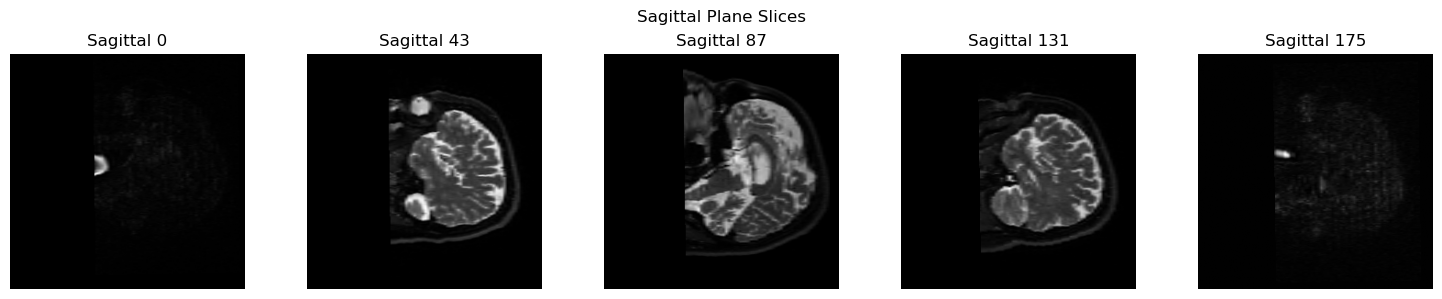

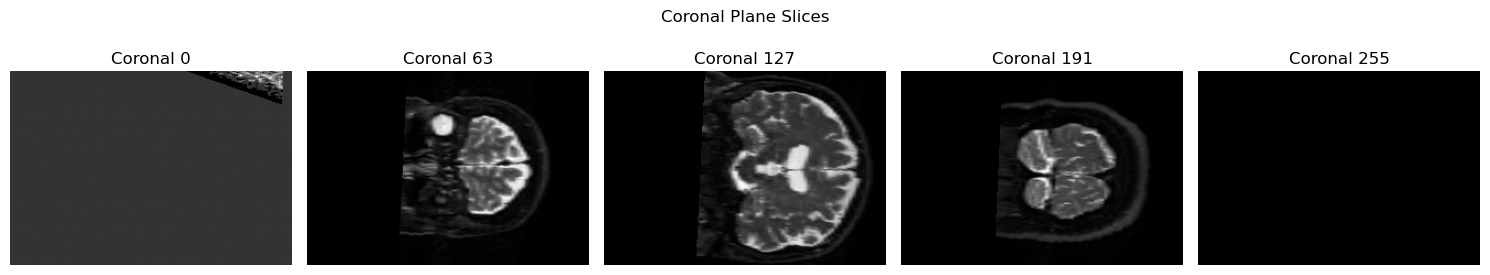

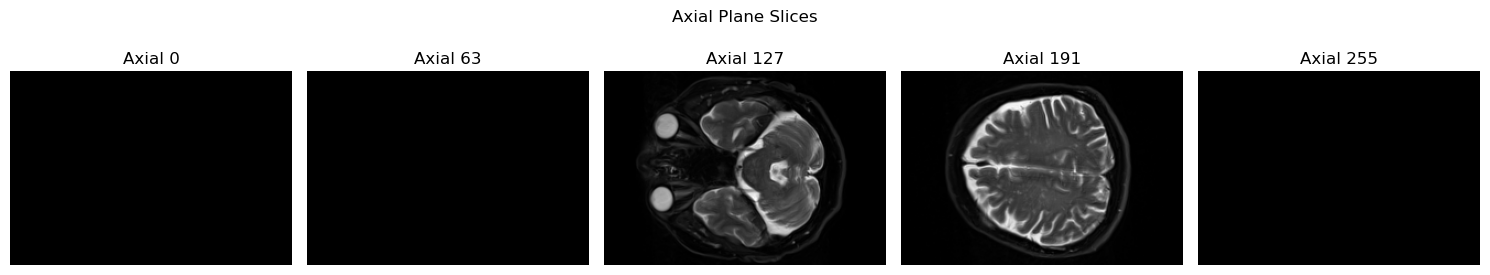

In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

# === Load a sample PD MRI scan ===
base_dir = r"D:\PD_dataset_split"
file_name = "I994202_PD.nii"  # Replace with a valid file from your dataset
file_path = os.path.join(base_dir, "train", "PD", file_name)

# Load the NIfTI file
img = nib.load(file_path)
data = img.get_fdata()

# Normalize for visualization
data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Get dimensions
x, y, z = data.shape
print(f"Image shape (sagittal, coronal, axial): {data.shape}")

# === Plot slices ===

def plot_plane_slices(data, axis, plane_name):
    plt.figure(figsize=(15, 3))
    slice_indices = np.linspace(0, data.shape[axis] - 1, 5, dtype=int)

    for i, idx in enumerate(slice_indices):
        plt.subplot(1, 5, i + 1)

        if plane_name == "sagittal":
            plt.imshow(data[idx, :, :], cmap="gray")
        elif plane_name == "coronal":
            plt.imshow(data[:, idx, :], cmap="gray")
        elif plane_name == "axial":
            plt.imshow(data[:, :, idx], cmap="gray")

        plt.title(f"{plane_name.capitalize()} {idx}")
        plt.axis("off")

    plt.suptitle(f"{plane_name.capitalize()} Plane Slices")
    plt.tight_layout()
    plt.show()

# Visualize all three views
plot_plane_slices(data, axis=0, plane_name="sagittal")
plot_plane_slices(data, axis=1, plane_name="coronal")
plot_plane_slices(data, axis=2, plane_name="axial")


In [2]:
import os
import nibabel as nib
import numpy as np
from PIL import Image
from tqdm import tqdm  # progress bar

# Paths
input_base_dir = r"D:\PD_dataset_split"
output_base_dir = r"D:\PD_slices_output"

# Valid classes and splits
labels = ["PD", "Control", "Prodromal"]
splits = ["train", "test", "val"]

# Useful slice ranges per plane
slice_ranges = {
    "axial": (100, 200),
    "coronal": (60, 190),
    "sagittal": (40, 135)
}

# Create output folders
for plane in slice_ranges.keys():
    for split in splits:
        for label in labels:
            out_dir = os.path.join(output_base_dir, plane, split, label)
            os.makedirs(out_dir, exist_ok=True)

# Helper function: Normalize & save a slice
def save_slice(slice_2d, output_path):
    slice_norm = (slice_2d - np.min(slice_2d)) / (np.max(slice_2d) - np.min(slice_2d) + 1e-8)
    slice_uint8 = (slice_norm * 255).astype(np.uint8)
    img = Image.fromarray(slice_uint8)
    img.save(output_path)

# Process each .nii file
for split in splits:
    for label in labels:
        folder = os.path.join(input_base_dir, split, label)
        if not os.path.exists(folder):
            continue

        print(f"\n📂 Processing {split}/{label} ...")
        for filename in tqdm(os.listdir(folder)):
            if not filename.endswith(".nii"):
                continue

            file_path = os.path.join(folder, filename)
            try:
                img = nib.load(file_path)
                data = img.get_fdata()
                base_id = os.path.splitext(filename)[0]  # remove .nii

                # Normalize whole volume
                data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)

                # Extract and save slices for each plane
                for plane, (start, end) in slice_ranges.items():
                    for i in range(start, min(end, data.shape["sagittal coronal axial".split().index(plane)])):
                        if plane == "axial":
                            slice_2d = data[:, :, i]
                        elif plane == "coronal":
                            slice_2d = data[:, i, :]
                        elif plane == "sagittal":
                            slice_2d = data[i, :, :]
                        else:
                            continue

                        out_path = os.path.join(output_base_dir, plane, split, label, f"{base_id}_{plane}_{i}.png")
                        save_slice(slice_2d, out_path)

            except Exception as e:
                print(f"⚠️ Error with {file_path}: {e}")

print("\n✅ All slices extracted and saved successfully!")



📂 Processing train/PD ...


100%|██████████| 258/258 [07:45<00:00,  1.81s/it]



📂 Processing train/Control ...


100%|██████████| 94/94 [02:42<00:00,  1.73s/it]



📂 Processing train/Prodromal ...


...


📂 Processing val/Control ...


100%|██████████| 15/15 [00:27<00:00,  1.82s/it]



📂 Processing val/Prodromal ...


100%|██████████| 8/8 [00:15<00:00,  1.98s/it]


✅ All slices extracted and saved successfully!


In [3]:
import os
import re

# Paths
input_base_dir = r"D:\PD_dataset_split"
output_base_dir = r"D:\PD_slices_output"

# Slice ranges
slice_ranges = {
    "axial": (100, 200),
    "coronal": (60, 190),
    "sagittal": (40, 135)
}

splits = ["train", "test", "val"]
labels = ["PD", "Control", "Prodromal"]

# Counter trackers
expected_counts = {}
actual_counts = {}
missing_files = []
extra_files = []

# Regex to match slice filenames
pattern = re.compile(r"^(I\d+_[a-zA-Z]+)_(axial|coronal|sagittal)_(\d+)\.png$")

# Step 1: Calculate expected slices
print("\n🔍 Calculating expected slices...")
for split in splits:
    for label in labels:
        nii_dir = os.path.join(input_base_dir, split, label)
        if not os.path.exists(nii_dir):
            continue

        for fname in os.listdir(nii_dir):
            if not fname.endswith(".nii"):
                continue

            base_id = os.path.splitext(fname)[0]
            for plane, (start, end) in slice_ranges.items():
                expected_counts.setdefault((plane, split, label), 0)
                expected_counts[(plane, split, label)] += end - start

# Step 2: Count actual PNGs
print("📁 Counting saved slices...")
for plane in slice_ranges:
    for split in splits:
        for label in labels:
            folder = os.path.join(output_base_dir, plane, split, label)
            if not os.path.exists(folder):
                continue
            count = 0
            for fname in os.listdir(folder):
                match = pattern.match(fname)
                if match:
                    file_plane = match.group(2)
                    if file_plane != plane:
                        extra_files.append(os.path.join(folder, fname))
                    count += 1
                else:
                    extra_files.append(os.path.join(folder, fname))

            actual_counts[(plane, split, label)] = count

# Step 3: Compare and report
print("\n📊 Verification Report")
print("------------------------")

total_expected = sum(expected_counts.values())
total_actual = sum(actual_counts.values())

for key in sorted(expected_counts):
    plane, split, label = key
    exp = expected_counts[key]
    act = actual_counts.get(key, 0)
    status = "✅ OK" if exp == act else "❌ MISMATCH"
    print(f"{plane.capitalize():<9} | {split:<5} | {label:<10} | Expected: {exp:<4} | Actual: {act:<4} | {status}")

print("\n📦 Total expected slices:", total_expected)
print("📦 Total actual slices  :", total_actual)

if extra_files:
    print(f"\n⚠️ Extra or misnamed files found: {len(extra_files)}")
    for f in extra_files[:5]:
        print(f" - {f}")
    if len(extra_files) > 5:
        print("...and more.")

print("\n✅ Verification complete.")



🔍 Calculating expected slices...
📁 Counting saved slices...

📊 Verification Report
------------------------
Axial     | test  | Control    | Expected: 1100 | Actual: 1076 | ❌ MISMATCH
Axial     | test  | PD         | Expected: 3300 | Actual: 3300 | ✅ OK
Axial     | test  | Prodromal  | Expected: 500  | Actual: 500  | ✅ OK
Axial     | train | Control    | Expected: 9400 | Actual: 9400 | ✅ OK
Axial     | train | PD         | Expected: 25800 | Actual: 25728 | ❌ MISMATCH
Axial     | train | Prodromal  | Expected: 4600 | Actual: 4576 | ❌ MISMATCH
Axial     | val   | Control    | Expected: 1500 | Actual: 1500 | ✅ OK
Axial     | val   | PD         | Expected: 2800 | Actual: 2800 | ✅ OK
Axial     | val   | Prodromal  | Expected: 800  | Actual: 800  | ✅ OK
Coronal   | test  | Control    | Expected: 1430 | Actual: 1430 | ✅ OK
Coronal   | test  | PD         | Expected: 4290 | Actual: 4290 | ✅ OK
Coronal   | test  | Prodromal  | Expected: 650  | Actual: 650  | ✅ OK
Coronal   | train | Control    

In [4]:
import os
import nibabel as nib
import numpy as np

# Paths
input_base_dir = r"D:\PD_dataset_split"
output_base_dir = r"D:\PD_slices_output"
slice_range = (100, 200)  # Axial slice range
splits = ["train", "test", "val"]
labels = ["PD", "Control", "Prodromal"]

missing_slices_log = []

print("\n🔍 Checking axial slice extraction integrity...\n")

for split in splits:
    for label in labels:
        nii_folder = os.path.join(input_base_dir, split, label)
        png_folder = os.path.join(output_base_dir, "axial", split, label)

        if not os.path.exists(nii_folder):
            continue

        for fname in os.listdir(nii_folder):
            if not fname.endswith(".nii"):
                continue

            nii_path = os.path.join(nii_folder, fname)
            base_id = os.path.splitext(fname)[0]
            expected_count = slice_range[1] - slice_range[0]
            actual_count = 0
            try:
                img = nib.load(nii_path)
                data = img.get_fdata()

                if data.shape[2] < slice_range[1]:
                    missing = expected_count - (data.shape[2] - slice_range[0])
                    actual_count = data.shape[2] - slice_range[0]
                    missing_slices_log.append((split, label, fname, f"Only {data.shape[2]} slices available", missing))
                    continue

                # Count saved axial slices
                for i in range(slice_range[0], slice_range[1]):
                    png_name = f"{base_id}_axial_{i}.png"
                    png_path = os.path.join(png_folder, png_name)
                    if os.path.exists(png_path):
                        actual_count += 1

                if actual_count < expected_count:
                    missing = expected_count - actual_count
                    missing_slices_log.append((split, label, fname, "Some slices missing", missing))

            except Exception as e:
                missing_slices_log.append((split, label, fname, f"⚠️ Error reading file: {e}", expected_count))

# Report
print("📋 Axial Slice Missing Report")
print("-----------------------------------------")
for entry in missing_slices_log:
    split, label, fname, reason, missing = entry
    print(f"[{split}/{label}] {fname} → Missing: {missing} slices | Reason: {reason}")

print(f"\n🔎 Total files with issues: {len(missing_slices_log)}")



🔍 Checking axial slice extraction integrity...

📋 Axial Slice Missing Report
-----------------------------------------
[train/PD] I428489_PD.nii → Missing: 24 slices | Reason: Only 176 slices available
[train/PD] I696540_PD.nii → Missing: 24 slices | Reason: Only 176 slices available
[train/PD] I696858_PD.nii → Missing: 24 slices | Reason: Only 176 slices available
[train/Prodromal] I696907_Prodromal.nii → Missing: 24 slices | Reason: Only 176 slices available
[test/Control] I409983_Control.nii → Missing: 24 slices | Reason: Only 176 slices available

🔎 Total files with issues: 5


d:\Anaconda\envs\py310\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Found 39704 images belonging to 3 classes.
Found 5100 images belonging to 3 classes.
Found 4876 images belonging to 3 classes.
Epoch 1/10
1241/1241 [==============================] - 270s 207ms/step - loss: 0.7312 - accuracy: 0.6547 - val_loss: 0.7478 - val_accuracy: 0.5675
Epoch 2/10
1241/1241 [==============================] - 250s 201ms/step - loss: 0.6263 - accuracy: 0.7040 - val_loss: 0.7499 - val_accuracy: 0.6041
Epoch 3/10
1241/1241 [==============================] - 251s 202ms/step - loss: 0.5484 - accuracy: 0.7475 - val_loss: 0.7098 - val_accuracy: 0.6053
Epoch 4/10
1241/1241 [==============================] - 251s 202ms/step - loss: 0.4799 - accuracy: 0.7855 - val_loss: 0.6918 - val_accuracy: 0.6424
Epoch 5/10
1241/1241 [==============================] - 265s 214ms/step - loss: 0.4244 - accuracy: 0.8170 - val_loss: 0.6513 - val_accuracy: 0.6704
Epoch 6/10
1241/1241 [==============================] - 195s 157ms/step - loss: 0.3705 - accuracy: 0.8458 - val_loss: 0.7022 - val_ac

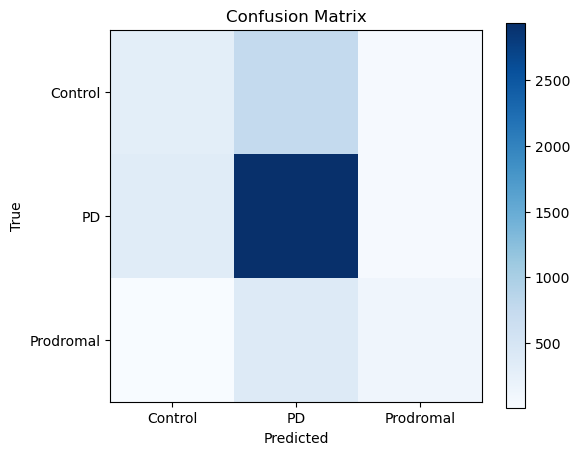

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# Path to your axial data
base_dir = r"D:\PD_slices_output\axial"

# Image generators
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)
val_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "val"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)
test_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# Load base model
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(3, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

# Evaluate
print("\n🔍 Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")

# Classification report
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)
class_labels = list(test_gen.class_indices.keys())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks(ticks=np.arange(3), labels=class_labels)
plt.yticks(ticks=np.arange(3), labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [8]:
# Save model in HDF5 format
model.save("vgg16_axial_model_2.h5")
print("✅ Model saved as vgg16_axial_model_2.h5")


✅ Model saved as vgg16_axial_model_2.h5


Found 51740 images belonging to 3 classes.
Found 6630 images belonging to 3 classes.
Found 6370 images belonging to 3 classes.
Epoch 1/10
1617/1617 [==============================] - 250s 154ms/step - loss: 0.7232 - accuracy: 0.6529 - val_loss: 0.7641 - val_accuracy: 0.5721
Epoch 2/10
1617/1617 [==============================] - 351s 217ms/step - loss: 0.6202 - accuracy: 0.7062 - val_loss: 0.7890 - val_accuracy: 0.6090
Epoch 3/10
1617/1617 [==============================] - 748s 463ms/step - loss: 0.5466 - accuracy: 0.7470 - val_loss: 0.8168 - val_accuracy: 0.6024
Epoch 4/10
1617/1617 [==============================] - 256s 158ms/step - loss: 0.4752 - accuracy: 0.7879 - val_loss: 0.8378 - val_accuracy: 0.6009
Epoch 5/10
1617/1617 [==============================] - 262s 162ms/step - loss: 0.4255 - accuracy: 0.8144 - val_loss: 0.8398 - val_accuracy: 0.6178
Epoch 6/10
1617/1617 [==============================] - 252s 156ms/step - loss: 0.3764 - accuracy: 0.8393 - val_loss: 0.8870 - val_ac

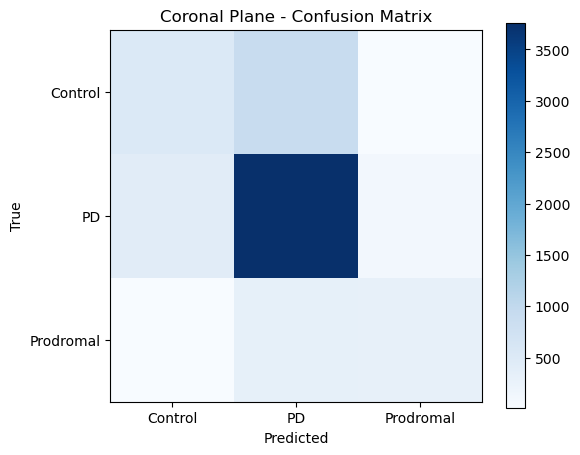

In [4]:
# ----------------- CORONAL VERSION -----------------

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# Set to coronal data
plane = "coronal"
base_dir = rf"D:\PD_slices_output\{plane}"

# Image generators
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "train"), target_size=(224, 224),
    batch_size=32, class_mode="categorical"
)
val_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "val"), target_size=(224, 224),
    batch_size=32, class_mode="categorical"
)
test_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "test"), target_size=(224, 224),
    batch_size=32, class_mode="categorical", shuffle=False
)

# Load pretrained VGG16
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(3, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Compile & train
model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[])

# Save the model
model_path = f"vgg16_{plane}_model.h5"
model.save(model_path)
print(f"✅ Model saved as {model_path}")

# Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Coronal Test Accuracy: {test_acc:.4f}")

# Classification Report
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)
class_labels = list(test_gen.class_indices.keys())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"{plane.capitalize()} Plane - Confusion Matrix")
plt.xticks(ticks=np.arange(3), labels=class_labels)
plt.yticks(ticks=np.arange(3), labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


Found 37810 images belonging to 3 classes.
Found 4845 images belonging to 3 classes.
Found 4655 images belonging to 3 classes.
Epoch 1/10
1182/1182 [==============================] - 179s 151ms/step - loss: 0.6838 - accuracy: 0.6753 - val_loss: 0.7455 - val_accuracy: 0.5777
Epoch 2/10
1182/1182 [==============================] - 191s 161ms/step - loss: 0.5396 - accuracy: 0.7545 - val_loss: 0.7705 - val_accuracy: 0.5866
Epoch 3/10
1182/1182 [==============================] - 196s 166ms/step - loss: 0.4340 - accuracy: 0.8143 - val_loss: 0.7622 - val_accuracy: 0.6237
Epoch 4/10
1182/1182 [==============================] - 197s 167ms/step - loss: 0.3561 - accuracy: 0.8550 - val_loss: 0.7925 - val_accuracy: 0.6378
Epoch 5/10
1182/1182 [==============================] - 199s 168ms/step - loss: 0.2902 - accuracy: 0.8861 - val_loss: 0.8374 - val_accuracy: 0.6433
Epoch 6/10
1182/1182 [==============================] - 199s 168ms/step - loss: 0.2343 - accuracy: 0.9113 - val_loss: 0.8725 - val_ac

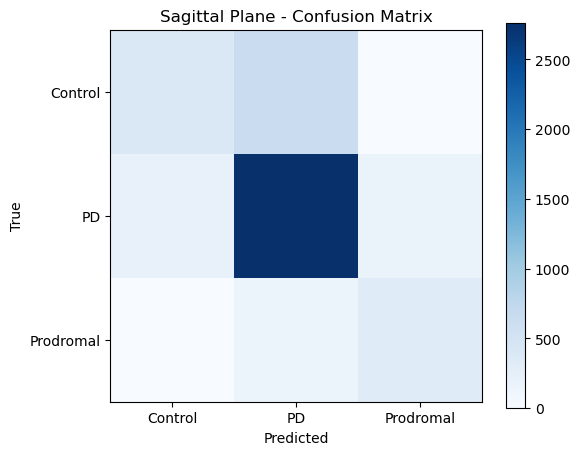

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# --------- SETTINGS ---------
plane = "sagittal"
base_dir = rf"D:\PD_slices_output\{plane}"

# --------- DATA LOADERS ---------
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "train"), target_size=(224, 224),
    batch_size=32, class_mode="categorical"
)
val_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "val"), target_size=(224, 224),
    batch_size=32, class_mode="categorical"
)
test_gen = datagen.flow_from_directory(
    os.path.join(base_dir, "test"), target_size=(224, 224),
    batch_size=32, class_mode="categorical", shuffle=False
)

# --------- MODEL SETUP ---------
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(3, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# --------- TRAINING ---------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[]
)

# --------- SAVE MODEL ---------
model_path = f"vgg16_{plane}_model.h5"
model.save(model_path)
print(f"✅ Model saved as {model_path}")

# --------- EVALUATION ---------
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ {plane.capitalize()} Test Accuracy: {test_acc:.4f}")

# --------- METRICS ---------
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)
class_labels = list(test_gen.class_indices.keys())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# --------- CONFUSION MATRIX ---------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"{plane.capitalize()} Plane - Confusion Matrix")
plt.xticks(ticks=np.arange(3), labels=class_labels)
plt.yticks(ticks=np.arange(3), labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [2]:
import tensorflow as tf

# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to avoid memory allocation issues
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"TensorFlow is using GPU: {tf.config.experimental.get_device_details(gpus[0])['device_name']}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found for TensorFlow.")

d:\Anaconda\envs\py310\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow is using GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Found 39704 images belonging to 3 classes.
Found 5100 images belonging to 3 classes.
Found 4876 images belonging to 3 classes.
Epoch 1/10
1240/1240 [==============================] - 273s 209ms/step - loss: 0.7553 - accuracy: 0.6504 - val_loss: 0.7870 - val_accuracy: 0.5505
Epoch 2/10
1240/1240 [==============================] - 257s 207ms/step - loss: 0.6582 - accuracy: 0.6837 - val_loss: 0.7336 - val_accuracy: 0.5743
Epoch 3/10
1240/1240 [==============================] - 258s 208ms/step - loss: 0.5968 - accuracy: 0.7123 - val_loss: 0.7085 - val_accuracy: 0.5932
Epoch 4/10
1240/1240 [==============================] - 259s 209ms/step - loss: 0.5372 - accuracy: 0.7446 - val_loss: 0.6776 - val_accuracy: 0.6336
Epoch 5/10
1240/1240 [==============================] - 259s 209ms/step - loss: 0.4998 - accuracy: 0.7673 - val_loss: 0.6745 - val_accuracy: 0.6297
Epoch 6/10
1240/1240 [==============================] - 261s 211ms/step - loss: 0.4579 - accuracy: 0.7923 - val_loss: 0.7054 - val_ac

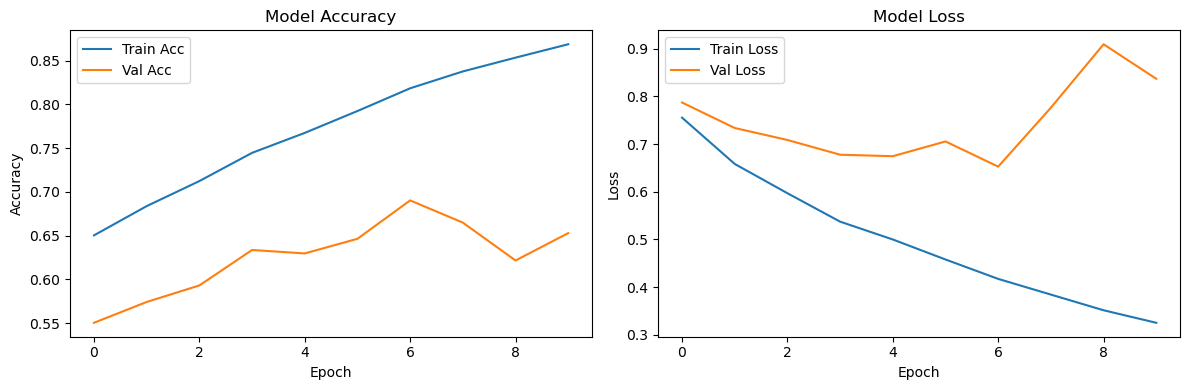

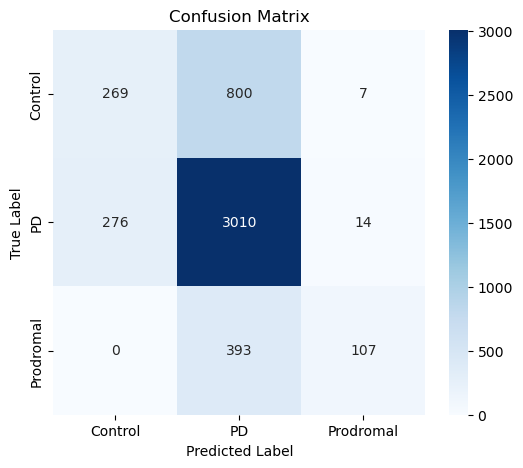

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score

# Set paths to axial data
train_dir = r"D:\PD_slices_output\axial\train"
val_dir = r"D:\PD_slices_output\axial\val"
test_dir = r"D:\PD_slices_output\axial\test"

# Basic parameters
img_size = (224, 224)
batch_size = 32
num_classes = 3
epochs = 10  # Increase for better results

# Create image generators
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=False
)

# Load pretrained VGG16 without top
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Optional: checkpoint saving
checkpoint = ModelCheckpoint('Vgg16_Axial_Best_Model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

# Train the model
history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // batch_size,
    validation_data=val_gen,
    validation_steps=val_gen.samples // batch_size,
    epochs=epochs,
    callbacks=[checkpoint]
)

# Save the final model
model.save('Vgg16_Axial_Final_Model.h5')

# Evaluate on test data
test_gen.reset()
preds = model.predict(test_gen, steps=test_gen.samples // batch_size + 1, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes[:len(y_pred)]

# Accuracy, precision, recall
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')

print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

# Plot training accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Found 51740 images belonging to 3 classes.
Found 6630 images belonging to 3 classes.
Found 6370 images belonging to 3 classes.
Epoch 1/10
1616/1616 [==============================] - 354s 218ms/step - loss: 0.7241 - accuracy: 0.6522 - val_loss: 0.7965 - val_accuracy: 0.5610
Epoch 2/10
1616/1616 [==============================] - 300s 186ms/step - loss: 0.6367 - accuracy: 0.6910 - val_loss: 0.7552 - val_accuracy: 0.6114
Epoch 3/10
1616/1616 [==============================] - 315s 195ms/step - loss: 0.5716 - accuracy: 0.7265 - val_loss: 0.8261 - val_accuracy: 0.5921
Epoch 4/10
1616/1616 [==============================] - 689s 426ms/step - loss: 0.5162 - accuracy: 0.7567 - val_loss: 0.7964 - val_accuracy: 0.6114
Epoch 5/10
1616/1616 [==============================] - 901s 558ms/step - loss: 0.4692 - accuracy: 0.7831 - val_loss: 0.8285 - val_accuracy: 0.6167
Epoch 6/10
1616/1616 [==============================] - 283s 175ms/step - loss: 0.4240 - accuracy: 0.8063 - val_loss: 0.8782 - val_ac

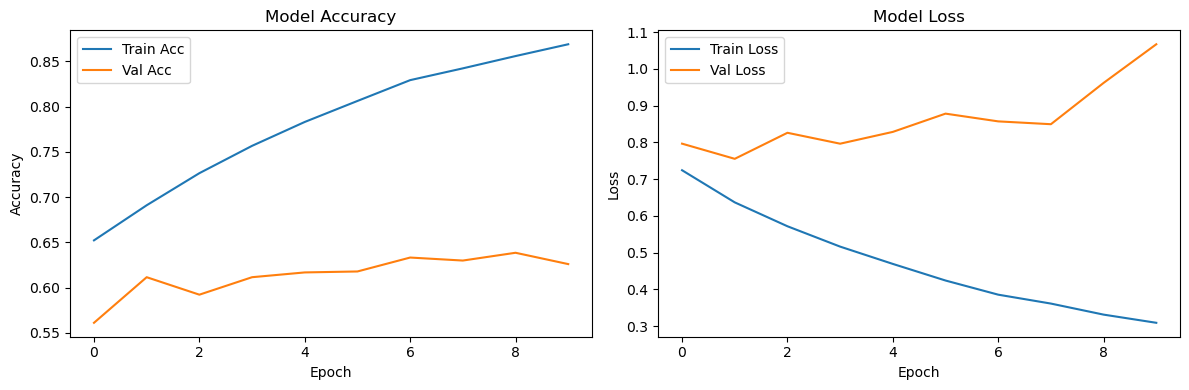

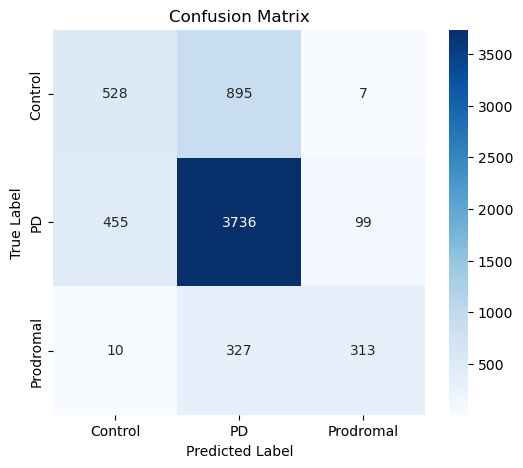

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score

# Set paths to coronal data
train_dir = r"D:\PD_slices_output\coronal\train"
val_dir = r"D:\PD_slices_output\coronal\val"
test_dir = r"D:\PD_slices_output\coronal\test"

# Basic parameters
img_size = (224, 224)
batch_size = 32
num_classes = 3
epochs = 10  # Increase for better results

# Create image generators
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=False
)

# Load pretrained VGG16 without top
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Optional: checkpoint saving
checkpoint = ModelCheckpoint('Vgg16_Coronal_Best_Model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

# Train the model
history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // batch_size,
    validation_data=val_gen,
    validation_steps=val_gen.samples // batch_size,
    epochs=epochs,
    callbacks=[checkpoint]
)

# Save the final model
model.save('Vgg16_Coronal_Final_Model.h5')

# Evaluate on test data
test_gen.reset()
preds = model.predict(test_gen, steps=test_gen.samples // batch_size + 1, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes[:len(y_pred)]

# Accuracy, precision, recall
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')

print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

# Plot training accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


d:\Anaconda\envs\py310\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Found 37810 images belonging to 3 classes.
Found 4845 images belonging to 3 classes.
Found 4655 images belonging to 3 classes.
Epoch 1/10
1181/1181 [==============================] - 256s 203ms/step - loss: 0.6961 - accuracy: 0.6722 - val_loss: 0.7625 - val_accuracy: 0.5567
Epoch 2/10
1181/1181 [==============================] - 237s 200ms/step - loss: 0.5661 - accuracy: 0.7412 - val_loss: 0.7605 - val_accuracy: 0.5805
Epoch 3/10
1181/1181 [==============================] - 212s 180ms/step - loss: 0.4797 - accuracy: 0.7911 - val_loss: 0.7648 - val_accuracy: 0.6024
Epoch 4/10
1181/1181 [==============================] - 208s 176ms/step - loss: 0.4073 - accuracy: 0.8284 - val_loss: 0.7952 - val_accuracy: 0.6089
Epoch 5/10
1181/1181 [==============================] - 1536s 1s/step - loss: 0.3519 - accuracy: 0.8561 - val_loss: 0.8273 - val_accuracy: 0.6246
Epoch 6/10
1181/1181 [==============================] - 192s 162ms/step - loss: 0.3050 - accuracy: 0.8795 - val_loss: 0.8159 - val_accu

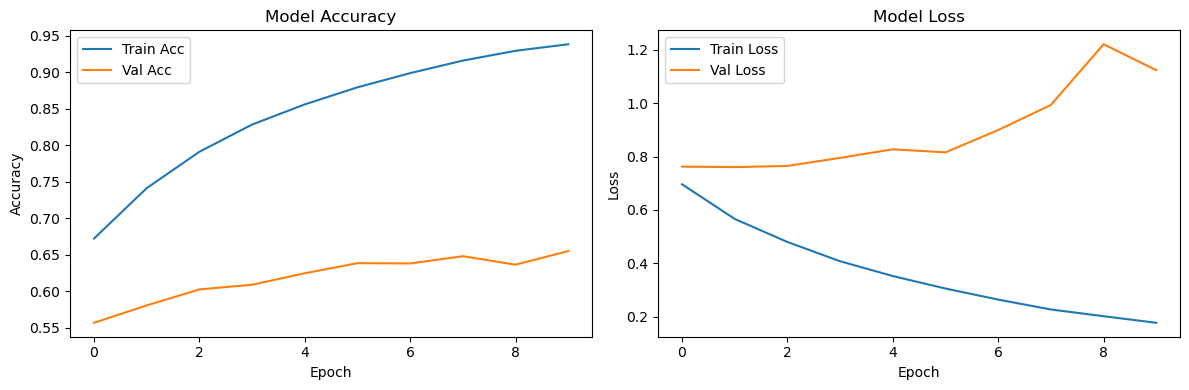

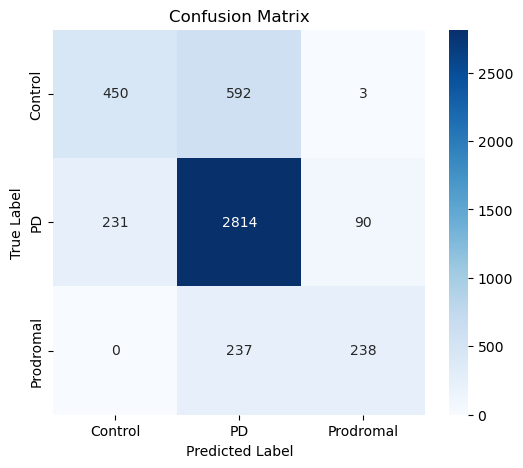

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score

# Set paths to sagittal data
train_dir = r"D:\PD_slices_output\sagittal\train"
val_dir = r"D:\PD_slices_output\sagittal\val"
test_dir = r"D:\PD_slices_output\sagittal\test"

# Basic parameters
img_size = (224, 224)
batch_size = 32
num_classes = 3
epochs = 10  # Increase for better results

# Create image generators
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=['Control', 'PD', 'Prodromal'],
    shuffle=False
)

# Load pretrained VGG16 without top
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Optional: checkpoint saving
checkpoint = ModelCheckpoint('Vgg16_Sagittal_Best_Model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

# Train the model
history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // batch_size,
    validation_data=val_gen,
    validation_steps=val_gen.samples // batch_size,
    epochs=epochs,
    callbacks=[checkpoint]
)

# Save the final model
model.save('Vgg16_Sagittal_Final_Model.h5')

# Evaluate on test data
test_gen.reset()
preds = model.predict(test_gen, steps=test_gen.samples // batch_size + 1, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes[:len(y_pred)]

# Accuracy, precision, recall
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')

print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

# Plot training accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [4]:
import os

base_dir = r"D:\PD_slices_output\sagittal\train"
total_images = 0

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith('.png'):
            total_images += 1

print("Total images in training folder:", total_images)


Total images in training folder: 37810


In [8]:
import os

base_dir = r"D:\PD_slices_output\sagittal\train"
class_names = ['Control', 'PD', 'Prodromal']
total_images = 0

for class_name in class_names:
    path = os.path.join(base_dir, class_name)  # No 'sagittal' subfolder here
    if os.path.exists(path):
        num_files = len([f for f in os.listdir(path) if f.lower().endswith('.png')])
        print(f"{class_name} images: {num_files}")
        total_images += num_files
    else:
        print(f"❌ Path not found: {path}")

print("Total sagittal images:", total_images)


Control images: 8930
PD images: 24510
Prodromal images: 4370
Total sagittal images: 37810
